# A Simple Tutorial for TIC

Welcome to **TIC (Temporal Inference of Cells)** — a Python toolkit for **graph‑based pseudo‑time analysis**, **micro‑environment feature engineering**, and **causal inference** on spatial‑omics data.

This notebook walks you through a *minimal‑yet‑complete* workflow **from raw spatial transcriptomics data to causal insights**.  
Each section pairs **concise code** with **detailed narrative** so you can **understand *why***, not just *how*.



## 1 Installation

TIC is tested with **Python ≥ 3.10** on Linux/macOS.  
It depends on **NumPy**, **SciPy**, **scanpy**, **PyTorch (optional)**, and a few light utilities.

```bash
# clone the repository
git clone https://github.com/cellethology/tic.git
cd tic

# develop mode install ‑‑ keeps your working copy editable
pip install -e .
```

> **Tip** If you prefer a fully reproducible environment, see `requirements.txt` for a Conda recipe.



## 2 Load single‑cell data (AnnData)

TIC expects a standard `AnnData` object with at least:

| field | description |
|-------|-------------|
| `X`   | **cells × genes** expression matrix (dense or CSR) |
| `var` | gene meta‑data; *at minimum* an `index` of gene names |
| `obsm['spatial']` | **x / y** coordinates per cell (pixels or μm) |

*Optional* — but recommended:

* `obs['cell_type']` → categorical cell identities used by certain feature extractors


In [1]:
import warnings
warnings.filterwarnings('ignore')  

In [2]:

# Download & cache the public CODEX‑UPMC dataset (~500 MB)  
# The first call may take 1-10 minutes(depends on your network speed); subsequent calls reuse ~/.cache/tic/
from tic.data import load_codex_dataset

adata = load_codex_dataset()
print(adata)
print("Unique cell types:", adata.obs['cell_type'].unique())


AnnData object with n_obs × n_vars = 4360 × 22
    obs: 'cell_id', 'cell_type', 'size'
    uns: 'tissue_id', 'data_level'
    obsm: 'spatial'
Unique cell types: ['Naive immune cell' 'Macrophage' 'Stromal / Fibroblast' 'CD4 T cell'
 'Tumor (Ki67+)' 'Tumor (CD20+)' 'Tumor (CD21+)' 'Tumor (Podo+)' 'B cell'
 'Tumor' 'APC' 'Lymph vessel' 'CD8 T cell' 'Unassigned' 'Vessel'
 'Granulocyte' 'Tumor (CD15+)']



### Clean the local dataset cache

```bash
# nuke *all* cached datasets
rm -rf ~/.cache/tic
```

or in Python:

```python
from tic.data import list_datasets, remove_cache, remove_dataset
list_datasets()      # see what's cached
remove_dataset("codex_upmc")   # delete one dataset
# remove_cache()     # delete everything
```



## 3 Micro‑environment feature extraction

TIC formalises feature engineering as **(i) neighbourhood definition** → **(ii) feature recipe**.

1. **Graph construction** — `tic.graph.pp.compute_neighbors`  
   *Examples*: *Voronoi* adjacency, *k‑NN*, *radius* graph …
2. **Sub‑graph extraction** — `tic.graph.tl.extract_subgraph`  
   Strategies ranging from simple *k‑hop* BFS to *torch‑geometric*’s fast CUDA kernels.
3. **Feature recipe** — a named bundle of extractors (gene counts, composition, …).

Below we use the built‑in recipe **`tme_default`** and a *radius* subgraph around **tumour cells**.


In [3]:

from tic.wrappers import FeatureWrapper
from tic.graph.utils import estimate_radius

# Heuristic: radius giving ~30 neighbours per centre cell
suggested_r = estimate_radius(adata)
print(f"Suggested radius ≈ {suggested_r:.1f} pixels")

fw = FeatureWrapper(
    recipe="tme_default",
    centre_types=["Tumor"],                 # tumour cells as micro‑environment centres
    graph_params={'method': 'voronoi'},     # image‑level graph
    subgraph_params={'strategy': 'radius', 'radius': suggested_r},
)
fea_adata = fw.fit(adata)
fea_adata


Suggested radius ≈ 102.4 pixels


AnnData object with n_obs × n_vars = 497 × 22
    obs: 'cell_id', 'cell_type', 'size'
    uns: 'feature_modes', 'graph_params', 'subgraph_params', 'X_predictors_names', 'X_predictors_meta'
    obsm: 'centre_gene', 'composition', 'neighbor_gene_sum', 'same_type_gene_sum', 'same_type_gene_average', 'celltype_gene_count', 'X_predictors'


## 4 Pseudo‑time inference

TIC offers a **plug‑and‑play wrapper** around a multi‑step pipeline:

| step | default | purpose |
|------|---------|---------|
| Dimensionality reduction | PCA | compress high‑D features |
| Clustering | k‑means | discover meta‑states along transition |
| Graph learning | Slingshot | principal curve through clusters |
| Metrics | monotonicity / trend | quantify biomarker dynamics |

Use `.plot()` to colour the embedding by pseudotime or cluster labels.


2025-05-15 17:09:56,997 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
100%|██████████| 10/10 [00:00<00:00, 21.40it/s]


,biomarker,mono_method,mono_correlation,mono_p_value,trend_method,trend_trend,trend_statistic,trend_p_value
0,CD11b,spearman,-0.256228,6.837760e-09,mann_kendall,no_trend,1.883834,0.059587
1,CD14,spearman,0.323146,1.525054e-13,mann_kendall,decreasing,-2.239351,0.025133
2,CD15,spearman,-0.114791,1.043357e-02,mann_kendall,decreasing,-3.003374,0.002670
3,CD163,spearman,-0.715482,3.996394e-79,mann_kendall,no_trend,1.450185,0.147007
4,CD20,spearman,-0.417791,2.044189e-22,mann_kendall,no_trend,1.147928,0.250998


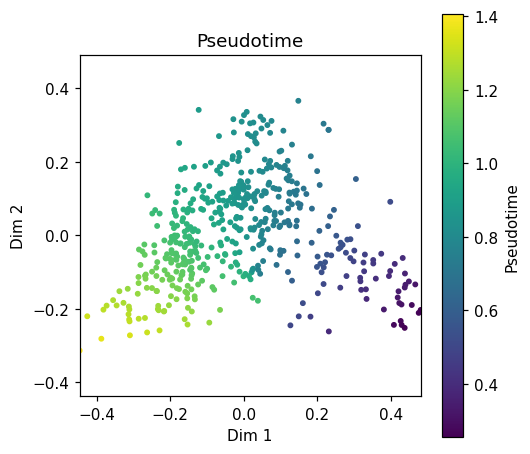

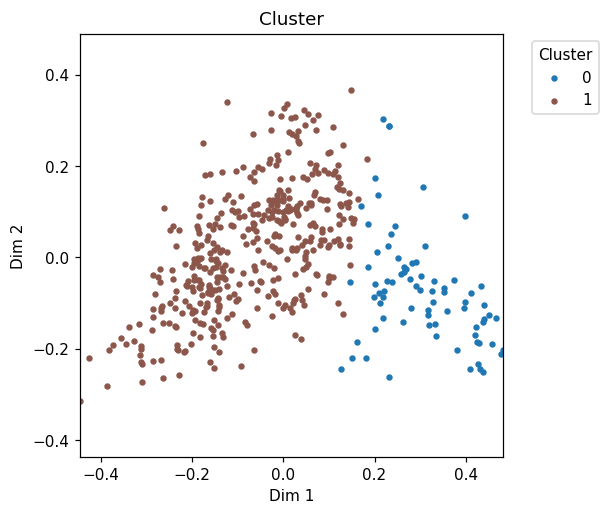

In [4]:

from tic.wrappers import PseudotimeWrapper

ptw = PseudotimeWrapper(
    rep_key="composition",        # 30‑D micro‑environment composition vectors
    output_dir="example_out",     # all artefacts saved here
)
pseudotime_adata = ptw.fit(fea_adata)

# quick visual checks
ptw.plot(kind="pseudotime")
ptw.plot(kind="cluster")

# inspect summary metrics
ptw.metrics.head()



## 5 Visualisation utilities

TIC ships opinionated plots for common tasks.

### 5.1 Monotonicity bar‑plot
Highlight top‑n biomarkers, always showing known epithelial / mesenchymal markers.


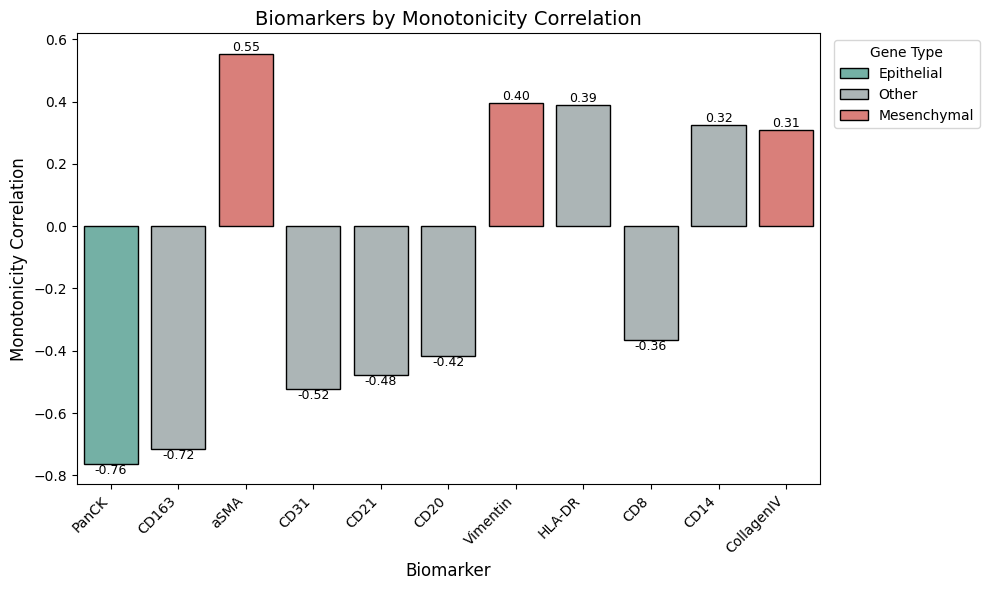

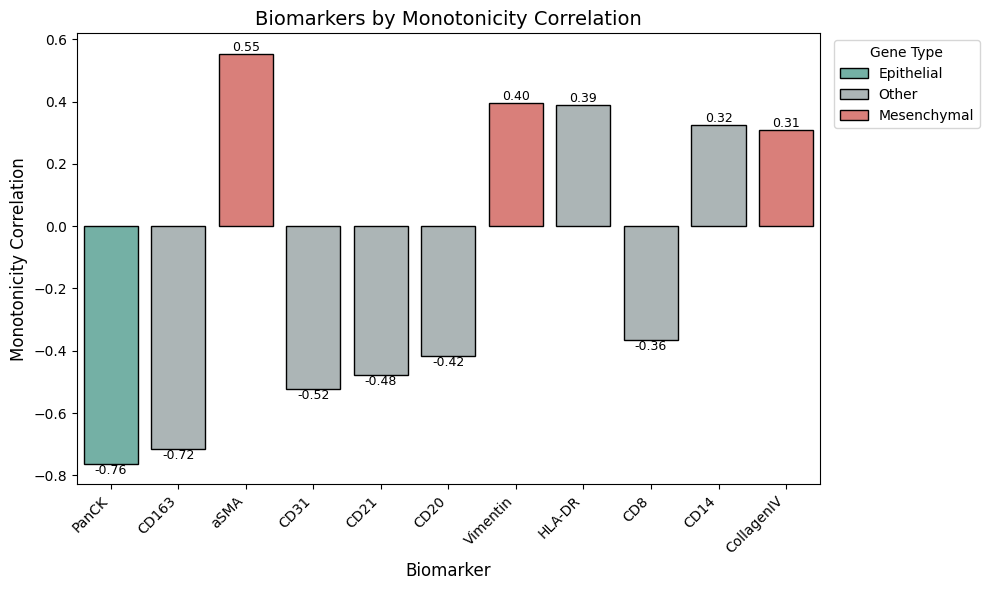

In [5]:

from tic.plotting import plot_monotonicity_metrics_bar
from utils.dataset.codex_upmc import UPMC_EPITHELIAL_GENES, UPMC_MESENCHYMAL_GENES

plot_monotonicity_metrics_bar(
    metrics=ptw.metrics,
    show_top_n=10,
    epithelial_genes=UPMC_EPITHELIAL_GENES,
    mesenchymal_genes=UPMC_MESENCHYMAL_GENES,
    save_path="example_out/monotonicity_bar.png",
)



### 5.2 Biomarker trajectories


<Axes: title={'center': 'Biomarker Trends Along Pseudotime'}, xlabel='Pseudotime', ylabel='Expression normalize'>

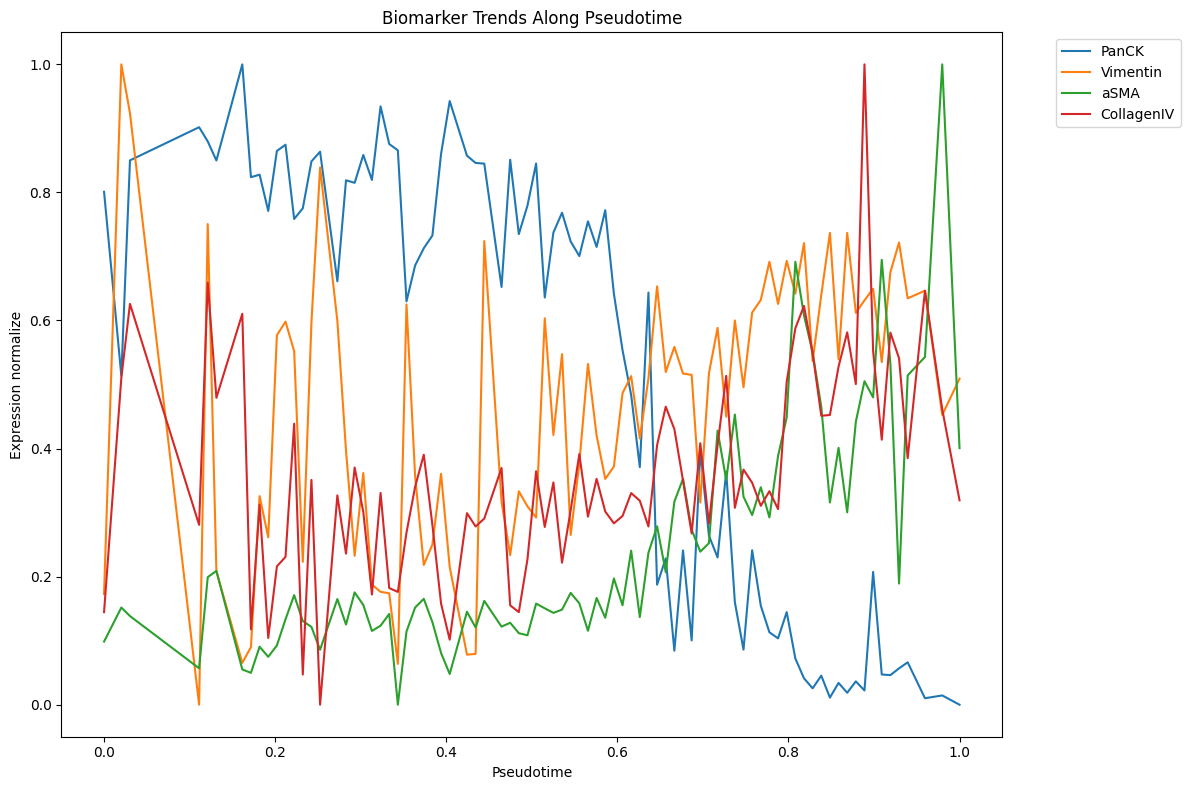

In [6]:

from tic.plotting import plot_biomarker_trends

plot_biomarker_trends(
    adata=pseudotime_adata,
    selected_biomarkers=UPMC_EPITHELIAL_GENES + UPMC_MESENCHYMAL_GENES,
    x_transform="bin+normalize",
    y_transform="normalize",
    bins=100,
    save_path="example_out/biomarker_vs_pt.png",
)



## 6 Causal inference

Finally, test **putative regulators → outcome biomarker** relationships across pseudo‑time bins.

Below we estimate **time‑lagged Granger causality** of micro‑environmental predictors on the *PanCK* epithelial marker.


No statistically significant predictors found (p ≥ 0.050).


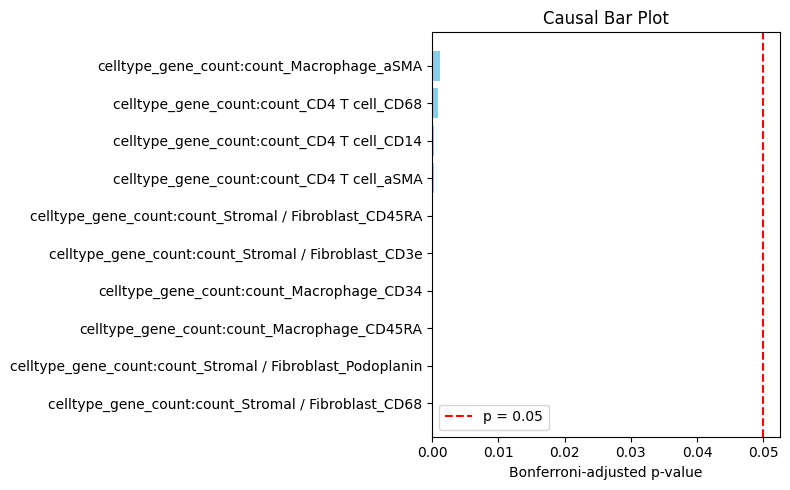

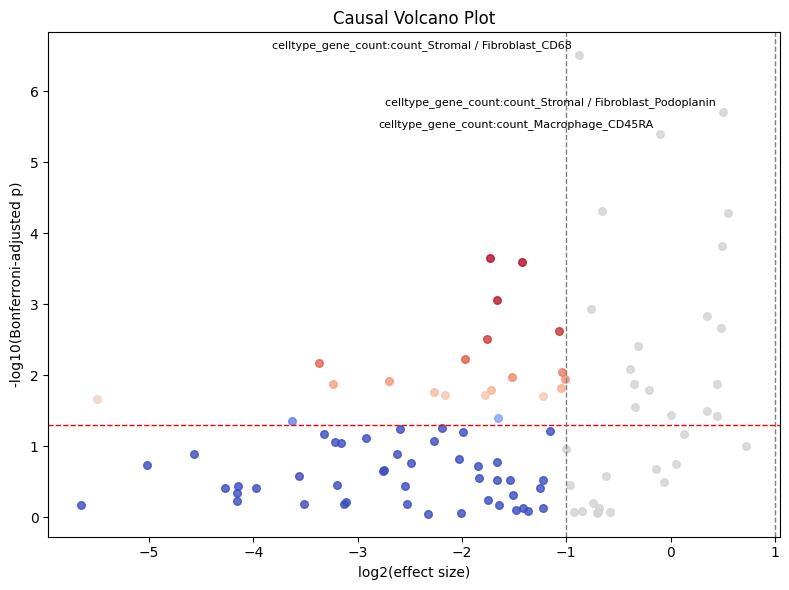

In [7]:

from tic.wrappers.causal import CausalWrapper

cw = CausalWrapper(
    outcome="PanCK",
    include_extractors=("celltype_gene_count",),  # focus on cell‑type densities
    method="granger_causality",
    bins=100,
    method_kwargs=dict(maxlag=3),
)
causal_adata = cw.fit(pseudotime_adata)

# three complementary visualisations
cw.plot(causal_adata, kind="bar")
cw.plot(causal_adata, kind="volcano")
cw.plot(causal_adata, kind="heatmap") # if no significant results, it will plot nothing



---

### That’s it!

You have:

1. **Loaded** spatial‑omics data  
2. **Engineered** micro‑environment features  
3. **Inferred** pseudo‑time trajectories  
4. **Visualised** biomarker dynamics  
5. **Quantified** causal drivers

Explore, tweak hyper‑parameters, and plug in your own data.  
Issues & pull‑requests welcome at [github.com/cellethology/tic](https://github.com/cellethology/tic).
